In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gpreda/bbc-news/bbc_news.csv


In [2]:
import pandas as pd

data_path = "/kaggle/input/datasets/gpreda/bbc-news/bbc_news.csv"
df = pd.read_csv(data_path)
df.head()


,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [3]:
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42115 entries, 0 to 42114
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        42115 non-null  object
 1   pubDate      42115 non-null  object
 2   guid         42115 non-null  object
 3   link         42115 non-null  object
 4   description  42115 non-null  object
dtypes: object(5)
memory usage: 1.6+ MB


title          0
pubDate        0
guid           0
link           0
description    0
dtype: int64

In [4]:
df["text"] = df["title"].astype(str) + " " + df["description"].astype(str)

print(df.shape)
df[["title", "description", "text"]].head(3)


(42115, 6)


,title,description,text
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,Ukraine: Angry Zelensky vows to punish Russian...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...",War in Ukraine: Taking cover in a town under a...
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,Ukraine war 'catastrophic for global food' One...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",   # drop common words like "the", "and"
    max_df=0.8,             # ignore words that appear in >80% of docs
    min_df=10               # ignore very rare words (<10 docs)
)

tfidf = vectorizer.fit_transform(df["text"])
tfidf.shape


(42115, 8198)

In [6]:
from sklearn.decomposition import NMF
import numpy as np

n_topics = 10
nmf = NMF(n_components=n_topics, random_state=0)
nmf_features = nmf.fit_transform(tfidf)

feature_names = vectorizer.get_feature_names_out()
n_top_words = 10

for topic_idx, topic in enumerate(nmf.components_):
    top_indices = np.argsort(topic)[::-1][:n_top_words]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Topic {topic_idx}: {' | '.join(top_words)}")


Topic 0: world | cup | final | women | 2022 | qatar | france | semi | finals | argentina
Topic 1: says | boss | president | secretary | government | office | ex | health | report | star
Topic 2: ukraine | war | russia | russian | putin | ukrainian | invasion | kyiv | president | zelensky
Topic 3: league | manchester | city | premier | united | champions | liverpool | win | arsenal | man
Topic 4: police | year | old | man | say | murder | woman | death | died | killed
Topic 5: week | days | seven | past | quiz | closely | going | attention | paying | selection
Topic 6: israel | gaza | hamas | israeli | hostages | attack | killed | war | people | bbc
Topic 7: england | euro | test | 2024 | day | win | wales | australia | final | nations
Topic 8: uk | cost | living | prices | rising | energy | rate | people | inflation | bills
Topic 9: election | sunak | minister | papers | rishi | labour | pm | prime | new | tory


In [7]:
df["topic"] = nmf_features.argmax(axis=1)
print(df["topic"].value_counts().sort_index())
df[["topic", "title"]].head(10)


topic
0    1932
1    4494
2    2599
3    4324
4    9777
5    1602
6    1730
7    3093
8    5784
9    6780
Name: count, dtype: int64


,topic,title
0,2,Ukraine: Angry Zelensky vows to punish Russian...
1,2,War in Ukraine: Taking cover in a town under a...
2,2,Ukraine war 'catastrophic for global food'
3,3,Manchester Arena bombing: Saffie Roussos's par...
4,8,Ukraine conflict: Oil price soars to highest l...
5,9,Ukraine war: PM to hold talks with world leade...
6,2,Ukraine war: UK grants 50 Ukrainian refugee vi...
7,2,TikTok limits services as Netflix pulls out of...
8,8,"Covid: Fourth jab for Scotland's vulnerable, a..."
9,2,Protests across Russia see thousands detained


In [8]:
row_idx = 5  # the index from the table

print("== Article ==")
print(df.loc[row_idx, ["topic", "title", "text"]], "\n")

print("== Topic weights ==")
for i, w in enumerate(nmf_features[row_idx]):
    print(f"Topic {i}: {w:.3f}")


== Article ==
topic                                                    9
title    Ukraine war: PM to hold talks with world leade...
text     Ukraine war: PM to hold talks with world leade...
Name: 5, dtype: object 

== Topic weights ==
Topic 0: 0.013
Topic 1: 0.000
Topic 2: 0.051
Topic 3: 0.000
Topic 4: 0.000
Topic 5: 0.000
Topic 6: 0.000
Topic 7: 0.000
Topic 8: 0.000
Topic 9: 0.054


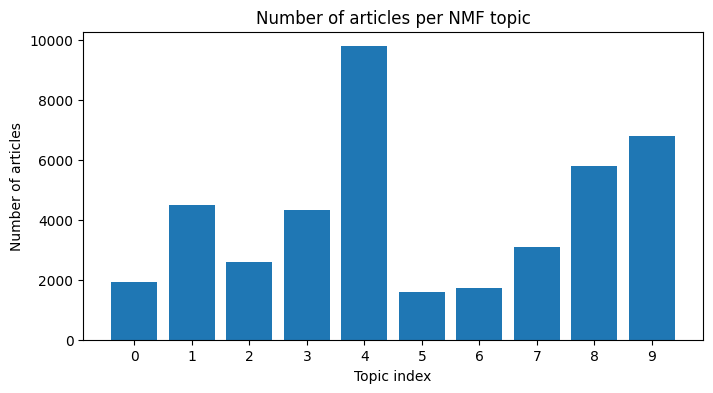

topic
0    1932
1    4494
2    2599
3    4324
4    9777
5    1602
6    1730
7    3093
8    5784
9    6780
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt

topic_counts = df["topic"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(topic_counts.index, topic_counts.values)
plt.xlabel("Topic index")
plt.ylabel("Number of articles")
plt.title("Number of articles per NMF topic")
plt.xticks(range(len(topic_counts)))
plt.show()

topic_counts


In [10]:
import numpy as np

df["pubDate_dt"] = pd.to_datetime(df["pubDate"], errors="coerce")
df["year"] = df["pubDate_dt"].dt.year

print("Rows, columns:", df.shape)
print("Date range:", df["pubDate_dt"].min(), "→", df["pubDate_dt"].max())
print("Articles per year:")
print(df["year"].value_counts().sort_index())


Rows, columns: (42115, 9)
Date range: 2013-08-30 01:01:55 → 2024-12-04 00:05:52
Articles per year:
year
2013        1
2017        1
2018        1
2019        1
2021        6
2022    12301
2023    15043
2024    14761
Name: count, dtype: int64


In [11]:
topic_counts = df["topic"].value_counts().sort_index()
print("Articles per topic:")
print(topic_counts, "\n")

topic_by_year = (
    df.pivot_table(index="year", columns="topic", values="title", aggfunc="count")
      .fillna(0)
      .astype(int)
)
topic_by_year


Articles per topic:
topic
0    1932
1    4494
2    2599
3    4324
4    9777
5    1602
6    1730
7    3093
8    5784
9    6780
Name: count, dtype: int64 



topic,0,1,2,3,4,5,6,7,8,9
year,,,,,,,,,,
2013,0,0,0,0,0,1,0,0,0,0
2017,0,0,0,0,0,0,0,0,0,1
2018,0,0,0,0,1,0,0,0,0,0
2019,0,0,0,0,0,1,0,0,0,0
2021,0,0,0,0,1,1,0,1,2,1
2022,839,1101,1422,1189,2328,481,121,976,2019,1825
2023,720,1671,686,1711,3689,600,819,966,2069,2112
2024,373,1722,491,1424,3758,518,790,1150,1694,2841


In [12]:
df["text_len"] = df["text"].str.len()

print("Text length (chars):")
print(df["text_len"].describe(percentiles=[0.25, 0.5, 0.75]).round(1), "\n")

print("Average text length by topic:")
print(df.groupby("topic")["text_len"].mean().round(1))


Text length (chars):
count    42115.0
mean       164.5
std         29.6
min         34.0
25%        147.0
50%        158.0
75%        174.0
max        332.0
Name: text_len, dtype: float64 

Average text length by topic:
topic
0    193.7
1    164.3
2    159.7
3    197.5
4    155.6
5    154.0
6    158.5
7    184.9
8    152.0
9    155.6
Name: text_len, dtype: float64


Articles per topic and year:
topic    0     1     2     3     4    5    6     7     8     9
year                                                          
2022   839  1101  1422  1189  2328  481  121   976  2019  1825
2023   720  1671   686  1711  3689  600  819   966  2069  2112
2024   373  1722   491  1424  3758  518  790  1150  1694  2841 



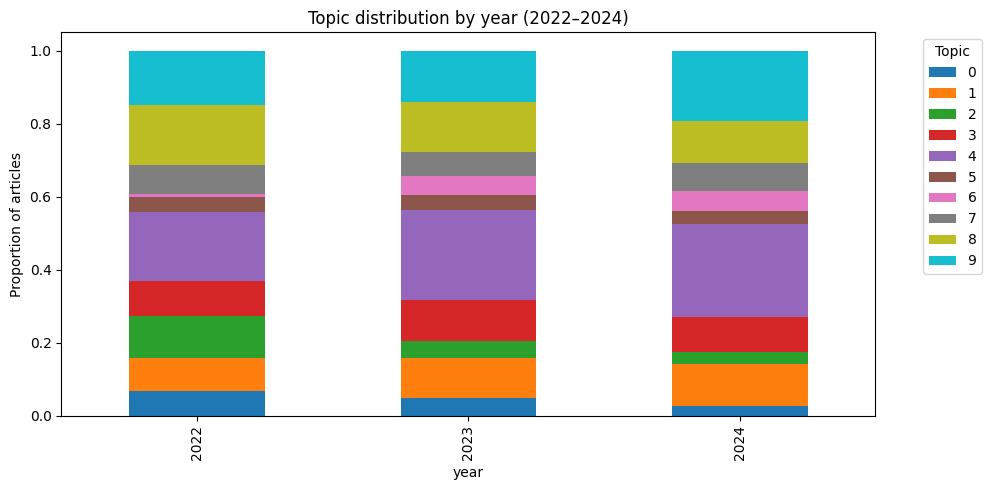

In [13]:
import matplotlib.pyplot as plt

years = [2022, 2023, 2024]
subset = df[df["year"].isin(years)]

topic_by_year = (
    subset.pivot_table(index="year", columns="topic", values="title", aggfunc="count")
          .fillna(0)
          .astype(int)
)

print("Articles per topic and year:")
print(topic_by_year, "\n")

props = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)

plt.figure(figsize=(10,5))
props.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="tab10")
plt.ylabel("Proportion of articles")
plt.title("Topic distribution by year (2022–2024)")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Article counts for topics 2 (Ukraine) and 6 (Gaza):
topic     2    6
year            
2022   1422  121
2023    686  819
2024    491  790 



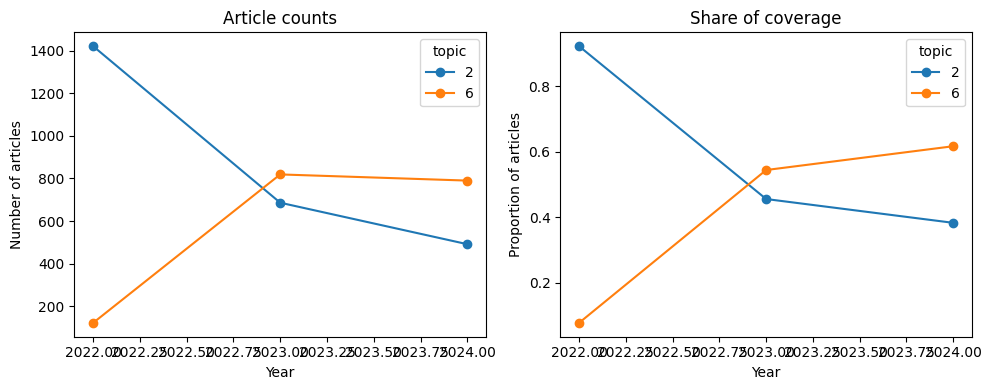

In [14]:
import matplotlib.pyplot as plt

years = [2022, 2023, 2024]
subset = df[df["year"].isin(years)]

topic_by_year = (
    subset.pivot_table(index="year", columns="topic", values="title", aggfunc="count")
          .fillna(0)
          .astype(int)
)

focus = topic_by_year[[2, 6]]
print("Article counts for topics 2 (Ukraine) and 6 (Gaza):")
print(focus, "\n")

# Line plot of counts and proportions
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

focus.plot(kind="line", marker="o", ax=axes[0])
axes[0].set_title("Article counts")
axes[0].set_ylabel("Number of articles")

(focus.div(focus.sum(axis=1), axis=0)).plot(kind="line", marker="o", ax=axes[1])
axes[1].set_title("Share of coverage")
axes[1].set_ylabel("Proportion of articles")

for ax in axes:
    ax.set_xlabel("Year")

plt.tight_layout()
plt.show()
